In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Social_Network_Ads - Social_Network_Ads.csv')
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [2]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [5]:
X =  df.drop('Purchased',axis=1)
y = df['Purchased']

In [7]:
scaler.fit(X)
scaled_features = scaler.transform(X)

In [8]:
df_feat = pd.DataFrame(scaled_features,columns=df.columns[:-1])
df_feat.head()

,Age,EstimatedSalary
0,-1.781797,-1.490046
1,-0.253587,-1.460681
2,-1.113206,-0.785290
3,-1.017692,-0.374182
4,-1.781797,0.183751


In [10]:
from sklearn.model_selection import train_test_split
X=df_feat
X_train, X_test, y_train, y_test  =train_test_split(scaled_features,y,
                                                   test_size=0.30,random_state=101)

In [11]:
print(X_train.shape)
print(X_test.shape) 

(280, 2)
(120, 2)


In [12]:
print(y_train.shape)
print(y_test.shape)

(280,)
(120,)


In [13]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
pred = knn.predict(X_test)

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,pred))

[[71  9]
 [ 1 39]]


In [16]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.99      0.89      0.93        80
           1       0.81      0.97      0.89        40

    accuracy                           0.92       120
   macro avg       0.90      0.93      0.91       120
weighted avg       0.93      0.92      0.92       120



In [17]:
print("Misclassification error rate:",round(np.mean(pred!=y_test),3))

Misclassification error rate: 0.083


In [18]:
error_rate=[]
accuratei=[]
for i in range(1,10):

    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i=knn.predict(X_test)
    error_rate.append(np.mean(pred_i!=y_test))
    accuratei.append(np.mean(pred_i==y_test))

Text(0, 0.5, 'Error(misclassification) Rate')

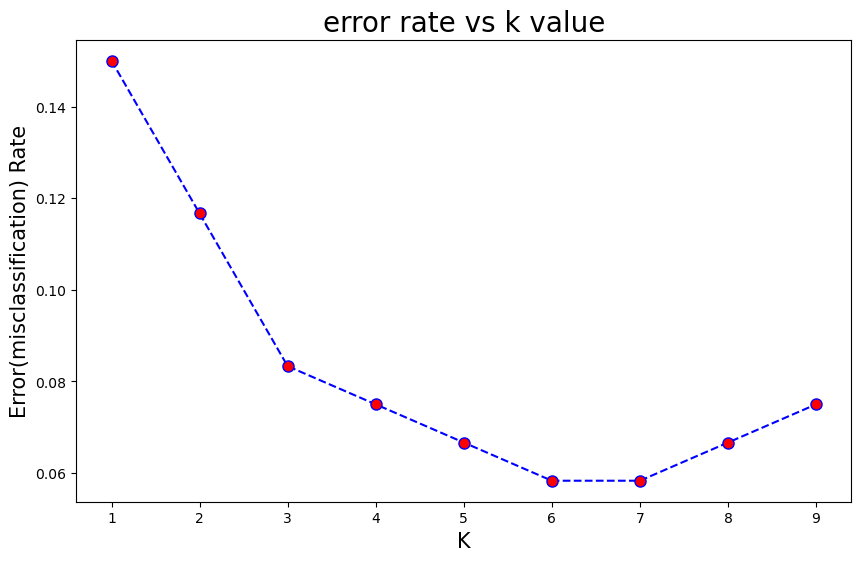

In [19]:
plt.figure(figsize=(10,6))
plt.plot(range(1,10),error_rate,color='blue',linestyle='dashed',
        marker='o',markerfacecolor='red',markersize=8)
plt.title('error rate vs k value',fontsize=20)
plt.xlabel('K',fontsize=15)
plt.ylabel('Error(misclassification) Rate',fontsize=15)

Text(0, 0.5, 'accuracy')

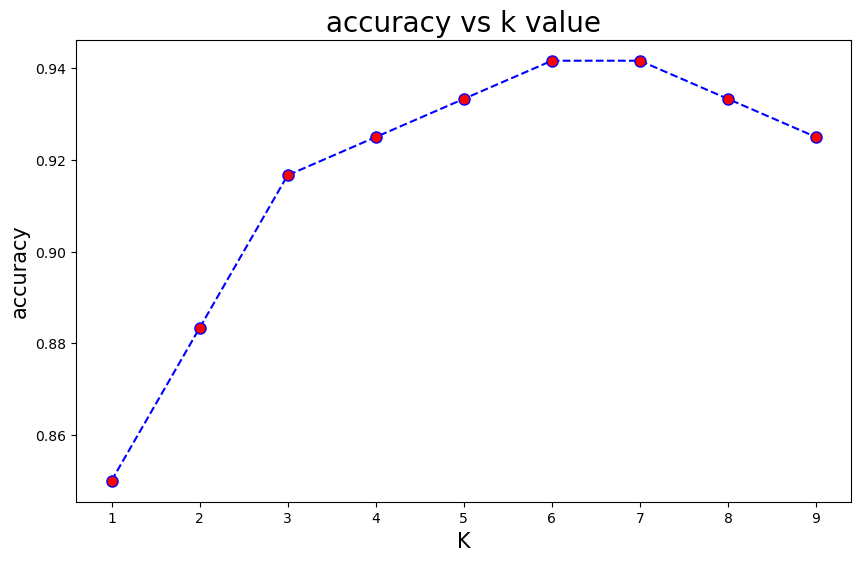

In [20]:
plt.figure(figsize=(10,6))
plt.plot(range(1,10),accuratei,color='blue',linestyle='dashed',
        marker='o',markerfacecolor='red',markersize=8)
plt.title('accuracy vs k value',fontsize=20)
plt.xlabel('K',fontsize=15)
plt.ylabel('accuracy',fontsize=15)